# Week 6 (Day 21) — Notebook 01
## Neural Network Fundamentals (Forward + Backprop) — NumPy Only

Goal: understand what a neural network is doing under the hood.

In this notebook you will:
- implement forward propagation for a tiny network
- compute a loss
- compute gradients (backprop intuition)
- do a few steps of gradient descent

> We use NumPy only here (no TensorFlow/PyTorch) so the math is visible.

## 6) MNIST Benchmark: From Scratch vs Libraries

This section extends the fundamentals into a practical benchmark:
- neural network **from scratch** (NumPy + backprop + gradient descent)
- neural network with **scikit-learn**
- neural network with **TensorFlow** (if installed)
- neural network with **PyTorch** (if installed)
- classical models for comparison

We compare:
- learning behavior (loss/error curves)
- learning-rate effects
- training speed
- final performance on held-out test data

In [13]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split


def load_mnist_data(max_train=12000, max_test=3000, random_state=42):
    """Load MNIST if available; fallback to sklearn digits if needed."""
    source = None

    # 1) TensorFlow MNIST (fast and reliable when tensorflow is available)
    try:
        from tensorflow.keras.datasets import mnist as keras_mnist

        (X_train, y_train), (X_test, y_test) = keras_mnist.load_data()
        X_train = X_train.reshape(-1, 28 * 28).astype("float32") / 255.0
        X_test = X_test.reshape(-1, 28 * 28).astype("float32") / 255.0
        source = "tensorflow.keras.datasets.mnist"
    except Exception:
        # 2) OpenML MNIST
        try:
            from sklearn.datasets import fetch_openml

            X_all, y_all = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
            X_all = X_all.astype("float32") / 255.0
            y_all = y_all.astype(int)

            X_train, X_test, y_train, y_test = train_test_split(
                X_all, y_all, test_size=10000, stratify=y_all, random_state=random_state
            )
            source = "openml:mnist_784"
        except Exception:
            # 3) Fallback to digits dataset
            from sklearn.datasets import load_digits

            digits = load_digits()
            X_all = (digits.data / 16.0).astype("float32")
            y_all = digits.target.astype(int)
            X_train, X_test, y_train, y_test = train_test_split(
                X_all, y_all, test_size=0.25, stratify=y_all, random_state=random_state
            )
            source = "sklearn.load_digits (fallback)"

    # optional downsampling for faster in-class execution
    rng_local = np.random.default_rng(random_state)

    if len(X_train) > max_train:
        idx_train = rng_local.choice(len(X_train), size=max_train, replace=False)
        X_train, y_train = X_train[idx_train], y_train[idx_train]

    if len(X_test) > max_test:
        idx_test = rng_local.choice(len(X_test), size=max_test, replace=False)
        X_test, y_test = X_test[idx_test], y_test[idx_test]

    n_classes = int(np.max(y_train)) + 1
    return X_train, y_train, X_test, y_test, n_classes, source


X_train_m, y_train_m, X_test_m, y_test_m, n_classes, data_source = load_mnist_data()
print(f"Data source: {data_source}")
print(f"Train shape: {X_train_m.shape}, Test shape: {X_test_m.shape}, Classes: {n_classes}")
print(pd.Series(y_train_m).value_counts().sort_index().to_string())

Data source: openml:mnist_784
Train shape: (12000, 784), Test shape: (3000, 784), Classes: 10
0    1182
1    1371
2    1197
3    1224
4    1159
5    1064
6    1182
7    1244
8    1181
9    1196


### 6.1 From-scratch NN (NumPy): Backprop + Gradient Descent on MNIST

We implement a 1-hidden-layer softmax classifier from scratch:
- forward pass: ReLU hidden + softmax output
- backward pass: analytical gradients
- optimization: mini-batch gradient descent

We also sweep learning rate to visualize:
- convergence behavior (loss curves)
- final test error
- training time

In [ ]:
def one_hot(y, num_classes):
    arr = np.zeros((len(y), num_classes), dtype=np.float32)
    arr[np.arange(len(y)), y.astype(int)] = 1.0
    return arr


def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
 
    exp_z = np.exp(z)

    temp_exp_sum = exp_z / np.sum(exp_z, axis=1, keepdims=True)
    return temp_exp_sum

#out_dim = 10
# y = w1X1 + W2+X2 + b1 + b2

def init_mlp(input_dim, hidden_dim, out_dim, seed=42):
    rng_local = np.random.default_rng(seed)

    W1 = rng_local.normal(0, np.sqrt(2 / input_dim), size=(input_dim, hidden_dim)).astype(np.float32)
    b1 = np.zeros((1, hidden_dim), dtype=np.float32)
    W2 = rng_local.normal(0, np.sqrt(2 / hidden_dim), size=(hidden_dim, out_dim)).astype(np.float32)
    b2 = np.zeros((1, out_dim), dtype=np.float32)
    return W1, b1, W2, b2


def forward_mlp(Xb, W1, b1, W2, b2):

    z1 = Xb @ W1 + b1
    a1 = np.maximum(0, z1) # ReLu = max(0, z)
    z2 = a1 @ W2 + b2
    probs = softmax(z2)
    cache = (Xb, z1, a1, probs)
    return probs, cache


def cross_entropy(probs, y_onehot):
    eps = 1e-9
    return -np.mean(np.sum(y_onehot * np.log(np.clip(probs, eps, 1 - eps)), axis=1))


def backward_mlp(cache, y_onehot, W2):
    Xb, z1, a1, probs = cache
    m = Xb.shape[0]

    dz2 = (probs - y_onehot) / m
    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)

    da1 = dz2 @ W2.T
    dz1 = da1 * (z1 > 0)
    dW1 = Xb.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    grad_norm = float(np.sqrt(np.sum(dW1**2) + np.sum(dW2**2)))
    return dW1, db1, dW2, db2, grad_norm


def predict_mlp(Xin, W1, b1, W2, b2):
    probs, _ = forward_mlp(Xin, W1, b1, W2, b2)
    return np.argmax(probs, axis=1)

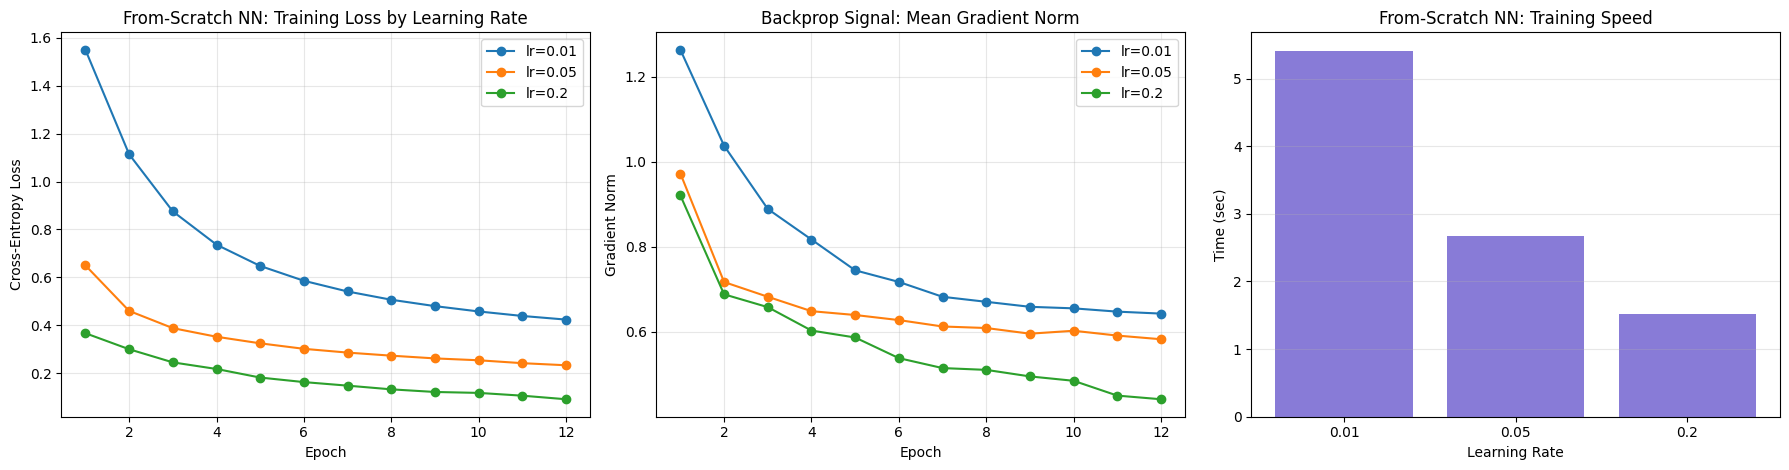

Best from-scratch learning rate: 0.2
From-scratch test accuracy: 0.9443 | time: 1.52s


In [ ]:

def train_mlp_from_scratch(
    X_train,
    y_train,
    X_test,
    y_test,
    hidden_dim=128,
    lr=0.05,
    epochs=12,
    batch_size=128,
    seed=42,
):
    input_dim = X_train.shape[1]
    out_dim = int(np.max(y_train)) + 1

    y_train_oh = one_hot(y_train, out_dim)
    y_test_oh = one_hot(y_test, out_dim)

    W1, b1, W2, b2 = init_mlp(input_dim, hidden_dim, out_dim, seed=seed)
    rng_local = np.random.default_rng(seed)

    train_loss_hist, test_loss_hist = [], []
    train_err_hist, test_err_hist = [], []
    grad_norm_hist = []

    t0 = time.perf_counter()
    n = len(X_train)

    for _ in range(epochs):
        idx = rng_local.permutation(n)
        Xs = X_train[idx]
        ys = y_train_oh[idx]

        epoch_grad_norms = []
        for i in range(0, n, batch_size):
            Xb = Xs[i : i + batch_size]
            yb = ys[i : i + batch_size]

            probs, cache = forward_mlp(Xb, W1, b1, W2, b2)
            dW1, db1, dW2, db2, gnorm = backward_mlp(cache, yb, W2)
            epoch_grad_norms.append(gnorm)

            W1 -= lr * dW1
            b1 -= lr * db1
            W2 -= lr * dW2
            b2 -= lr * db2

        tr_probs, _ = forward_mlp(X_train, W1, b1, W2, b2)
        te_probs, _ = forward_mlp(X_test, W1, b1, W2, b2)

        tr_loss = cross_entropy(tr_probs, y_train_oh)
        te_loss = cross_entropy(te_probs, y_test_oh)
        tr_pred = np.argmax(tr_probs, axis=1)
        te_pred = np.argmax(te_probs, axis=1)

        tr_err = 1 - accuracy_score(y_train, tr_pred)
        te_err = 1 - accuracy_score(y_test, te_pred)

        train_loss_hist.append(tr_loss)
        test_loss_hist.append(te_loss)
        train_err_hist.append(tr_err)
        test_err_hist.append(te_err)
        grad_norm_hist.append(float(np.mean(epoch_grad_norms)))

    elapsed = time.perf_counter() - t0

    return {
        "params": (W1, b1, W2, b2),
        "train_loss": np.array(train_loss_hist),
        "test_loss": np.array(test_loss_hist),
        "train_err": np.array(train_err_hist),
        "test_err": np.array(test_err_hist),
        "grad_norm": np.array(grad_norm_hist),
        "train_acc": 1 - float(train_err_hist[-1]),
        "test_acc": 1 - float(test_err_hist[-1]),
        "time_sec": elapsed,
    }


lr_grid = [0.01, 0.05, 0.20]
scratch_results = {}

for lr_val in lr_grid:
    scratch_results[lr_val] = train_mlp_from_scratch(
        X_train_m,
        y_train_m,
        X_test_m,
        y_test_m,
        hidden_dim=128,
        lr=lr_val,
        epochs=12,
        batch_size=128,
        seed=42,
    )

# Visualize LR effect: loss curves + gradient norm curves + speed
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

for lr_val in lr_grid:
    res = scratch_results[lr_val]
    ep = np.arange(1, len(res["train_loss"]) + 1)
    axes[0].plot(ep, res["train_loss"], marker="o", label=f"lr={lr_val}")
    axes[1].plot(ep, res["grad_norm"], marker="o", label=f"lr={lr_val}")

axes[0].set_title("From-Scratch NN: Training Loss by Learning Rate")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title("Backprop Signal: Mean Gradient Norm")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Gradient Norm")
axes[1].grid(alpha=0.3)
axes[1].legend()

speed_df = pd.DataFrame(
    {
        "learning_rate": [str(v) for v in lr_grid],
        "time_sec": [scratch_results[v]["time_sec"] for v in lr_grid],
        "test_acc": [scratch_results[v]["test_acc"] for v in lr_grid],
    }
)

axes[2].bar(speed_df["learning_rate"], speed_df["time_sec"], color="slateblue", alpha=0.8)
axes[2].set_title("From-Scratch NN: Training Speed")
axes[2].set_xlabel("Learning Rate")
axes[2].set_ylabel("Time (sec)")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

best_lr = max(lr_grid, key=lambda v: scratch_results[v]["test_acc"])
best_scratch = scratch_results[best_lr]
print(f"Best from-scratch learning rate: {best_lr}")
print(f"From-scratch test accuracy: {best_scratch['test_acc']:.4f} | time: {best_scratch['time_sec']:.2f}s")

### 6.2 scikit-learn NN + Classical Baselines

We benchmark:
- `LogisticRegression` (classical linear baseline)
- `RandomForestClassifier` (classical nonlinear baseline)
- `MLPClassifier` (NN in scikit-learn)

For MLP, we vary learning rate to visualize training behavior and speed.

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
import warnings

benchmark_rows = []

# Classical baseline: Logistic Regression
t0 = time.perf_counter()
log_reg = LogisticRegression(max_iter=300)
log_reg.fit(X_train_m, y_train_m)
log_time = time.perf_counter() - t0
log_pred = log_reg.predict(X_test_m)

benchmark_rows.append(
    {
        "Model": "LogisticRegression",
        "Library": "sklearn",
        "Train Time (s)": log_time,
        "Test Accuracy": accuracy_score(y_test_m, log_pred),
        "Test F1 (macro)": f1_score(y_test_m, log_pred, average="macro"),
    }
)

# Classical baseline: Random Forest
t0 = time.perf_counter()
rf = RandomForestClassifier(n_estimators=220, random_state=42, n_jobs=-1)
rf.fit(X_train_m, y_train_m)
rf_time = time.perf_counter() - t0
rf_pred = rf.predict(X_test_m)

benchmark_rows.append(
    {
        "Model": "RandomForest",
        "Library": "sklearn",
        "Train Time (s)": rf_time,
        "Test Accuracy": accuracy_score(y_test_m, rf_pred),
        "Test F1 (macro)": f1_score(y_test_m, rf_pred, average="macro"),
    }
)

# Neural baseline: sklearn MLP with LR sweep
sk_mlp_grid = [0.001, 0.01, 0.05]
sk_mlp_res = {}

for lr_val in sk_mlp_grid:
    mlp = MLPClassifier(
        hidden_layer_sizes=(128,),
        activation="relu",
        solver="adam",
        learning_rate_init=lr_val,
        max_iter=20,
        random_state=42,
        verbose=False,
    )
    t0 = time.perf_counter()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        mlp.fit(X_train_m, y_train_m)
    elapsed = time.perf_counter() - t0

    pred = mlp.predict(X_test_m)
    acc = accuracy_score(y_test_m, pred)
    f1m = f1_score(y_test_m, pred, average="macro")

    sk_mlp_res[lr_val] = {
        "model": mlp,
        "loss_curve": np.array(mlp.loss_curve_),
        "time_sec": elapsed,
        "acc": acc,
        "f1_macro": f1m,
    }

best_sk_lr = max(sk_mlp_grid, key=lambda v: sk_mlp_res[v]["acc"])
best_sk_model = sk_mlp_res[best_sk_lr]["model"]
benchmark_rows.append(
    {
        "Model": f"Sklearn MLP (lr={best_sk_lr})",
        "Library": "sklearn",
        "Train Time (s)": sk_mlp_res[best_sk_lr]["time_sec"],
        "Test Accuracy": sk_mlp_res[best_sk_lr]["acc"],
        "Test F1 (macro)": sk_mlp_res[best_sk_lr]["f1_macro"],
    }
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for lr_val in sk_mlp_grid:
    lc = sk_mlp_res[lr_val]["loss_curve"]
    axes[0].plot(np.arange(1, len(lc) + 1), lc, marker="o", label=f"lr={lr_val}")

axes[0].set_title("sklearn MLP: Loss vs Iteration")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

speed_df_sk = pd.DataFrame(
    {
        "lr": [str(v) for v in sk_mlp_grid],
        "time_sec": [sk_mlp_res[v]["time_sec"] for v in sk_mlp_grid],
        "acc": [sk_mlp_res[v]["acc"] for v in sk_mlp_grid],
    }
)
axes[1].bar(speed_df_sk["lr"], speed_df_sk["time_sec"], color="teal", alpha=0.8)
axes[1].set_title("sklearn MLP: Training Speed")
axes[1].set_xlabel("Learning Rate")
axes[1].set_ylabel("Time (sec)")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best sklearn MLP learning rate: {best_sk_lr}")

NameError: name 'time' is not defined

### 6.3 TensorFlow NN (if available)

This cell is optional and runs only if TensorFlow is installed.
We train a simple dense network and log training loss/accuracy plus speed.

In [17]:
tf_available = False

try:
    import tensorflow as tf

    tf.random.set_seed(42)
    tf_available = True

    tf_model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(X_train_m.shape[1],)),
            tf.keras.layers.Dense(128, activation="relu"),
            tf.keras.layers.Dense(n_classes, activation="softmax"),
        ]
    )

    tf_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    t0 = time.perf_counter()
    tf_hist = tf_model.fit(
        X_train_m,
        y_train_m,
        validation_data=(X_test_m, y_test_m),
        epochs=8,
        batch_size=128,
        verbose=0,
    )
    tf_time = time.perf_counter() - t0

    tf_pred = np.argmax(tf_model.predict(X_test_m, verbose=0), axis=1)
    tf_acc = accuracy_score(y_test_m, tf_pred)
    tf_f1 = f1_score(y_test_m, tf_pred, average="macro")

    benchmark_rows.append(
        {
            "Model": "TensorFlow DenseNN",
            "Library": "tensorflow",
            "Train Time (s)": tf_time,
            "Test Accuracy": tf_acc,
            "Test F1 (macro)": tf_f1,
        }
    )

    plt.figure(figsize=(6.5, 4))
    plt.plot(tf_hist.history["loss"], marker="o", label="train_loss")
    plt.plot(tf_hist.history["val_loss"], marker="o", label="val_loss")
    plt.title("TensorFlow: Loss Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    print(f"TensorFlow test accuracy: {tf_acc:.4f} | time: {tf_time:.2f}s")

except Exception as e:
    print("TensorFlow not available in this environment. Skipping TF section.")
    print(f"Reason: {type(e).__name__}: {e}")

TensorFlow not available in this environment. Skipping TF section.
Reason: ModuleNotFoundError: No module named 'tensorflow'


### 6.4 PyTorch NN (if available)

This cell is optional and runs only if PyTorch is installed.
We train a small MLP and compare speed/performance to other implementations.

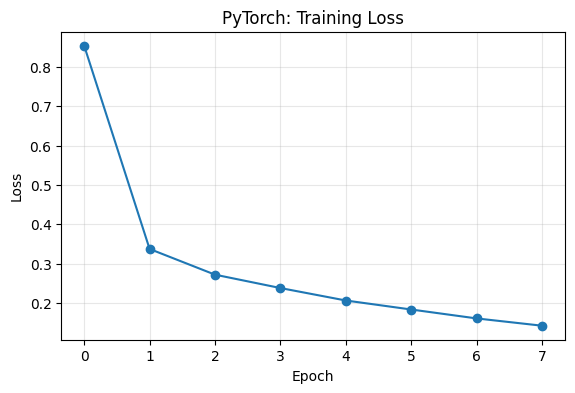

PyTorch test accuracy: 0.9327 | time: 1.80s | device: cuda


In [19]:
torch_available = False

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import TensorDataset, DataLoader

    torch_available = True
    torch.manual_seed(42)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    Xtr_t = torch.tensor(X_train_m, dtype=torch.float32)
    ytr_t = torch.tensor(y_train_m, dtype=torch.long)
    Xte_t = torch.tensor(X_test_m, dtype=torch.float32)
    yte_t = torch.tensor(y_test_m, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=128, shuffle=True)

    class TorchMLP(nn.Module):
        def __init__(self, in_dim, hidden_dim, out_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, out_dim),
            )

        def forward(self, x):
            return self.net(x)

    model_t = TorchMLP(X_train_m.shape[1], 128, n_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_t.parameters(), lr=1e-3)

    losses_t = []
    t0 = time.perf_counter()

    for _ in range(8):
        model_t.train()
        epoch_losses = []
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model_t(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            epoch_losses.append(float(loss.item()))

        losses_t.append(float(np.mean(epoch_losses)))

    torch_time = time.perf_counter() - t0

    model_t.eval()
    with torch.no_grad():
        logits_test = model_t(Xte_t.to(device)).cpu().numpy()
    torch_pred = np.argmax(logits_test, axis=1)

    torch_acc = accuracy_score(y_test_m, torch_pred)
    torch_f1 = f1_score(y_test_m, torch_pred, average="macro")

    benchmark_rows.append(
        {
            "Model": "PyTorch DenseNN",
            "Library": "pytorch",
            "Train Time (s)": torch_time,
            "Test Accuracy": torch_acc,
            "Test F1 (macro)": torch_f1,
        }
    )

    plt.figure(figsize=(6.5, 4))
    plt.plot(losses_t, marker="o")
    plt.title("PyTorch: Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(alpha=0.3)
    plt.show()

    print(f"PyTorch test accuracy: {torch_acc:.4f} | time: {torch_time:.2f}s | device: {device}")

except Exception as e:
    print("PyTorch not available in this environment. Skipping PyTorch section.")
    print(f"Reason: {type(e).__name__}: {e}")

### 6.5 Unified Comparison: Performance + Speed

Below we consolidate all available runs (from-scratch, sklearn, TensorFlow, PyTorch, and classical models) and compare:
- test accuracy / macro-F1
- training time

                    Model Library  Train Time (s)  Test Accuracy  Test F1 (macro)
    Sklearn MLP (lr=0.01) sklearn        4.056769       0.962333         0.961830
             RandomForest sklearn        2.203228       0.952000         0.951331
From Scratch MLP (lr=0.2)   numpy        1.522354       0.944333         0.943597
          PyTorch DenseNN pytorch        1.804103       0.932667         0.931821
       LogisticRegression sklearn       24.494214       0.907000         0.905919


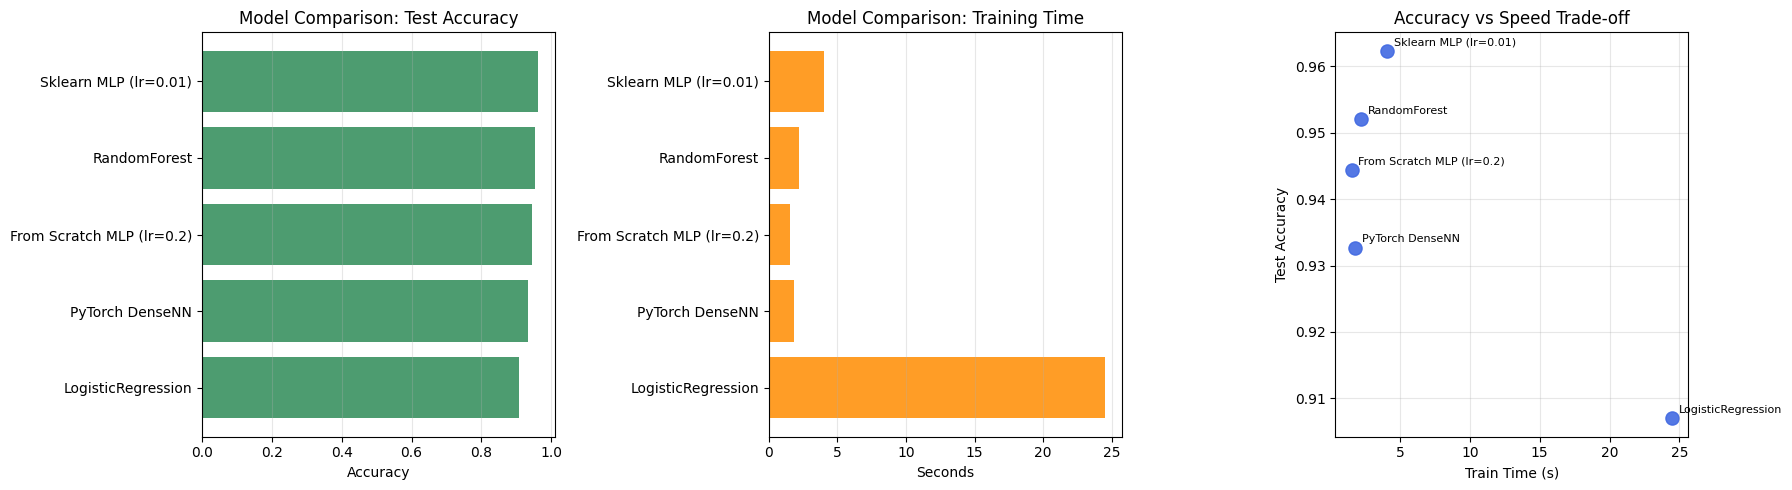

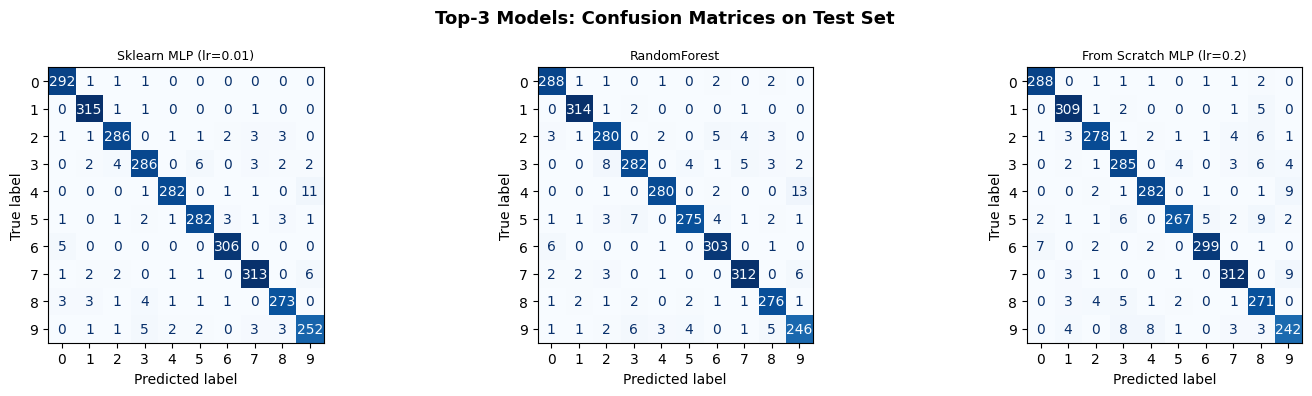


Notes:
- Accuracy compares predictive performance.
- Train time compares speed in this local environment.
- The scatter plot highlights the speed/accuracy frontier.


In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Add best from-scratch run to benchmark table
benchmark_rows.append(
    {
        "Model": f"From Scratch MLP (lr={best_lr})",
        "Library": "numpy",
        "Train Time (s)": best_scratch["time_sec"],
        "Test Accuracy": best_scratch["test_acc"],
        "Test F1 (macro)": f1_score(
            y_test_m,
            predict_mlp(X_test_m, *best_scratch["params"]),
            average="macro",
        ),
    }
)

bench_df = pd.DataFrame(benchmark_rows).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
print(bench_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(bench_df["Model"], bench_df["Test Accuracy"], color="seagreen", alpha=0.85)
axes[0].invert_yaxis()
axes[0].set_title("Model Comparison: Test Accuracy")
axes[0].set_xlabel("Accuracy")
axes[0].grid(axis="x", alpha=0.3)

axes[1].barh(bench_df["Model"], bench_df["Train Time (s)"], color="darkorange", alpha=0.85)
axes[1].invert_yaxis()
axes[1].set_title("Model Comparison: Training Time")
axes[1].set_xlabel("Seconds")
axes[1].grid(axis="x", alpha=0.3)

axes[2].scatter(bench_df["Train Time (s)"], bench_df["Test Accuracy"], s=90, color="royalblue", alpha=0.9)
for _, row in bench_df.iterrows():
    axes[2].annotate(row["Model"], (row["Train Time (s)"], row["Test Accuracy"]), fontsize=8, xytext=(5, 4), textcoords="offset points")
axes[2].set_title("Accuracy vs Speed Trade-off")
axes[2].set_xlabel("Train Time (s)")
axes[2].set_ylabel("Test Accuracy")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion matrices for top-3 models by accuracy
pred_map = {
    "LogisticRegression": log_pred,
    "RandomForest": rf_pred,
    f"Sklearn MLP (lr={best_sk_lr})": best_sk_model.predict(X_test_m),
    f"From Scratch MLP (lr={best_lr})": predict_mlp(X_test_m, *best_scratch["params"]),
}

if torch_available:
    pred_map["PyTorch DenseNN"] = torch_pred
if tf_available and "tf_pred" in globals():
    pred_map["TensorFlow DenseNN"] = tf_pred

top_models = [m for m in bench_df["Model"].head(3).tolist() if m in pred_map]
fig, axes = plt.subplots(1, len(top_models), figsize=(5 * len(top_models), 4))
if len(top_models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, top_models):
    cm = confusion_matrix(y_test_m, pred_map[model_name])
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(model_name, fontsize=9)

plt.suptitle("Top-3 Models: Confusion Matrices on Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nNotes:")
print("- Accuracy compares predictive performance.")
print("- Train time compares speed in this local environment.")
print("- The scatter plot highlights the speed/accuracy frontier.")

## 7) Mini-exercise (10–15 mins)
1) In **from-scratch MNIST**, try `lr` values `[0.005, 0.02, 0.1]` and compare convergence + final accuracy.
2) Increase hidden size from `128 -> 256` in one library implementation and observe speed/performance tradeoff.
3) Add one more classical baseline (e.g., `SVC` or `KNeighborsClassifier`) and update the final benchmark chart.
4) For the from-scratch model, plot **test error** along with **loss** and explain when they diverge.

Stop when you can clearly explain:
- what backprop computes
- how learning rate changes training dynamics
- why two models with similar accuracy can have very different training speed